In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

E0000 00:00:1749840345.689527   48137 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749840345.694152   48137 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749840345.707593   48137 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749840345.707623   48137 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749840345.707625   48137 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749840345.707627   48137 computation_placer.cc:177] computation placer already registered. Please check linka

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
dev = tf.config.list_physical_devices()
print('Physical Devices : ', dev)

tf.config.set_visible_devices(dev[0])
#tf.config.set_visible_devices(dev[1])
#dev = tf.config.list_logical_devices()
print('Available Devices : ', dev)

Physical Devices :  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Available Devices :  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Chapter 10: Deep Learning for Timeseries

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

In this section we turn to deep learning architecutures for modeling timeseries data.  A timeseries can be any data obtained
via measurements at regular intervals, like the daily price of a stock, hourly electricity consumption, or processing speech input.
A common task for a timeseries is forecasting, predicting what will hapen next in the series.  Recurrent layers are designed
specifically to process and predict time series data.

## 10.1 Different Kinds of Timeseries Tasks

A **timeseries** can be any data obtained via measurements at regular intervals.

Kinds of timeseries tasks:

- **Forecasting**: predicting what will happen next in a timeseries.
- **Classification**: Assign one or more categorical labels to a timeseries.
- **Event detection**: Identify the occurrence of a specific expected event within a continuous data stream.
- **Anomaly detection**: Detect anything unusual happenning within a continuous datastream.

## 10.2 A Temperature Forcasting Example

We’ll use a temperature-forecasting task to highlight what makes timeseries data
fundamentally different from the kinds of datasets you’ve encountered so far.
You'll see that densely connected networks and convolutional networks aren't well-equipped
to deal whith this kind of dataset.

Instead, a different kind of machine learning technique, recurrent neural networks (RNNs),
work well and are desigend for timeseries forcasting tasks.

We’ll work with a weather timeseries dataset recorded at the weather station at the
Max Planck Institute for Biogeochemistry in Jena, Germany.1 In this dataset, 14 different
quantities (such as temperature, pressure, humidity, wind direction, and so on)
were recorded every 10 minutes over several years. The original data goes back to
2003, but the subset of the data we’ll download is limited to 2009–2016.

The data is too large to put directly into our class project repository.  If you have
a linux command line, for example if you are using our clas DevEnvironment, you can use
`wget` to download and `unzip` to extract the file to our `data` subdirectory, as follows

```bash
vscode ➜ /workspaces/nndl/data (main) $ wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
--2025-06-13 15:28:50--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.216.153.254, 54.231.200.248, 52.216.41.200, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.216.153.254|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2016.csv.zip   100%[=========================================================>]  12.94M  2.27MB/s    in 8.4s    

2025-06-13 15:28:59 (1.55 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]


vscode ➜ /workspaces/nndl/data (main) $ unzip jena_climate_2009_2016.csv.zip 
Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  
```

The result is a 42M csv file named `jena_climate_2009_2016.csv` that is in your `data` subdirectory, which is where the following
code expects to find it.

Now let's inspect the data.  The text does some low-level reads and parsing of the data by hand, but lets use a Pandas DataFrame
so we can do a bit of data exploration.

In [4]:
fname = os.path.join('../data', 'jena_climate_2009_2016.csv')
data = pd.read_csv(fname)

# convert the string datetime date stamp to an actual datetime
data['Date Time'] = pd.to_datetime(data['Date Time'], format='%d.%m.%Y %H:%M:%S')

data.describe()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,420451,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000
mean,2012-12-30 01:10:03.507662592,989.212508,9.448567,283.491182,4.954011,76.007045,13.575089,9.532524,4.042483,6.021630,9.638982,1216.069883,2.130309,3.532381,174.726164
min,2009-01-01 00:10:00,913.600000,-23.010000,250.600000,-25.010000,12.950000,0.950000,0.790000,0.000000,0.500000,0.800000,1059.450000,0.000000,0.000000,0.000000
25%,2010-12-30 23:15:00,984.200000,3.360000,277.430000,0.240000,65.210000,7.780000,6.210000,0.870000,3.920000,6.290000,1187.490000,0.990000,1.760000,124.800000
50%,2012-12-29 22:00:00,989.570000,9.410000,283.460000,5.210000,79.300000,11.820000,8.860000,2.190000,5.590000,8.960000,1213.800000,1.760000,2.960000,198.100000
75%,2014-12-29 06:25:00,994.720000,15.470000,289.530000,10.070000,89.400000,17.600000,12.350000,5.300000,7.800000,12.480000,1242.770000,2.860000,4.740000,234.100000
max,2017-01-01 00:00:00,1015.350000,37.280000,311.340000,23.110000,100.000000,63.770000,28.320000,46.010000,18.130000,28.820000,1393.540000,14.630000,23.500000,360.000000
std,NaN,8.359454,8.423685,8.504820,6.730411,16.477126,7.739481,4.183895,4.897270,2.655973,4.235130,39.977065,1.541830,2.340482,86.675965


The figure shows the plot of temperature (in degrees Celsius) over time.  Using Pandas and actual `datetime` instances for our x axis makes
it easier to see the beginning of each year.  The data spans 8 years from Jan 01 2009 til Dec 31 2016.  But even without the
xtick labels, it is easy to pick out the yearly cycles and identify summer (max temperature) and winter (low temperature) recordings.

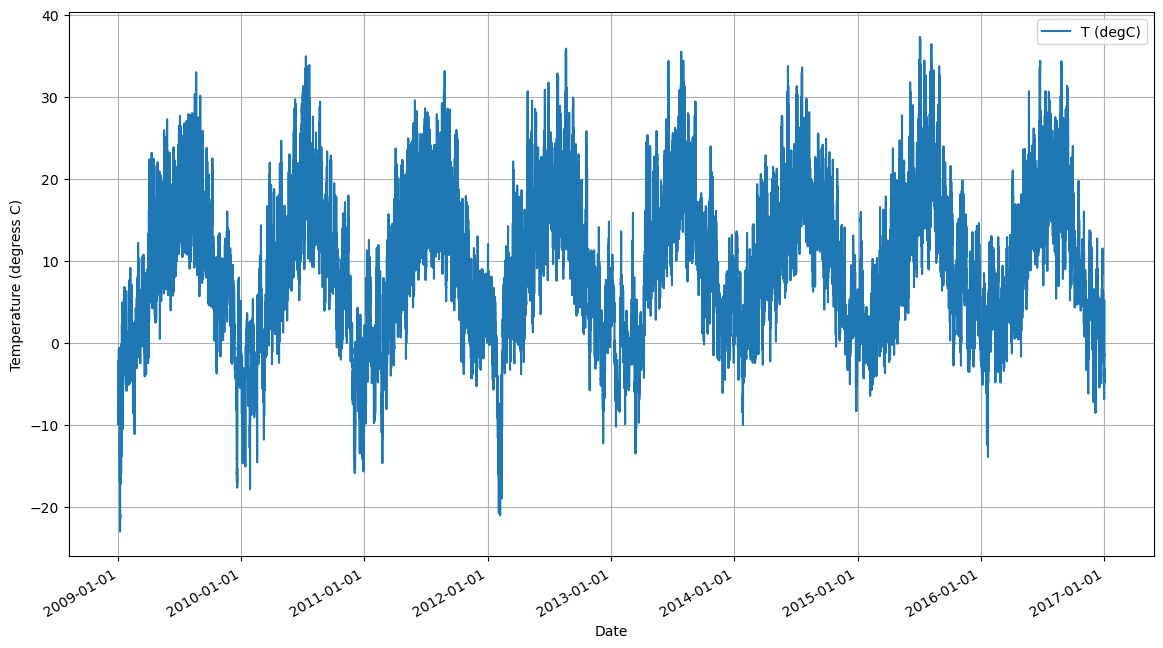

In [5]:
xticks = [datetime.date(year=y, month=1, day=1) for y in range(2009, 2018)]
data.plot(x='Date Time', y='T (degC)', figsize=(14,8), xticks=xticks)
plt.xlabel('Date')
plt.ylabel('Temperature (degress C)');
plt.grid();

In the following picture, we show the first 10 days of temperature data.  Data is recorded every 10 minutes, so you get $24 \times 6 = 144$
data points per day.

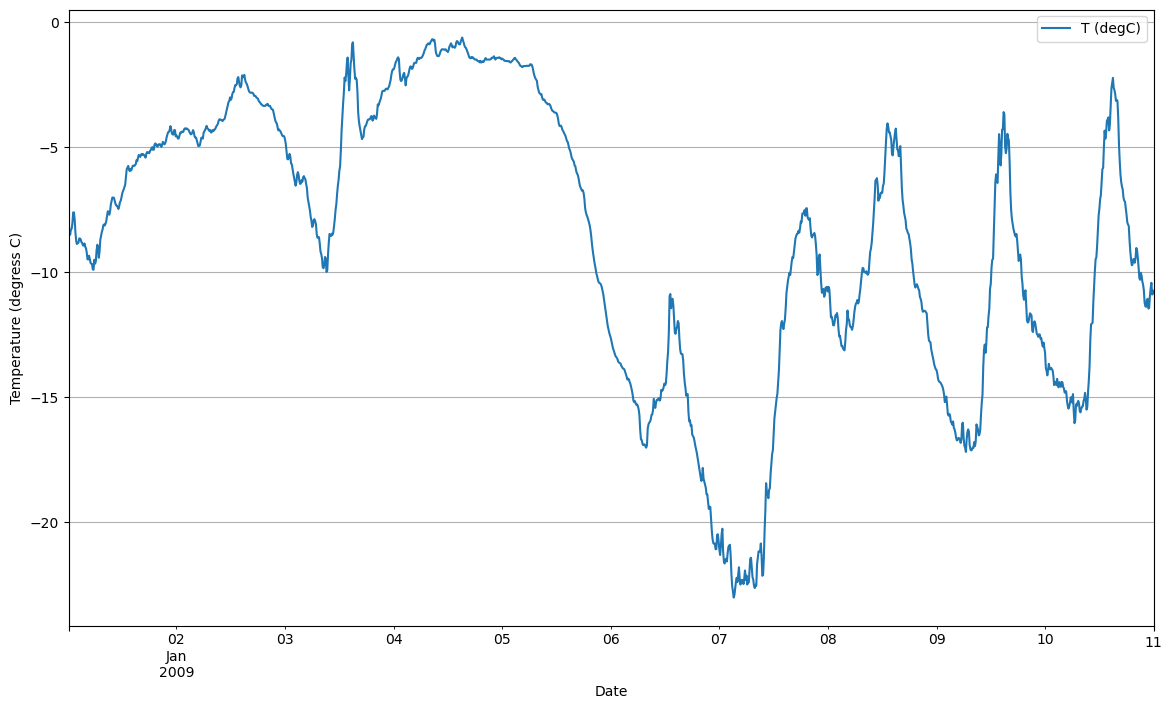

In [6]:
data.iloc[0:1440].plot(x='Date Time', y='T (degC)', figsize=(14,8))
plt.xlabel('Date')
plt.ylabel('Temperature (degress C)');
plt.grid();

On this plot, you can see the daily periodicity, especially for the last 4 day (warmer at noon, colder overnight).
Also note the temperature range, this 10-day period must be coming from a fairly cold winter month.

**Always look for periodicity in your data**: Periodicity over multiple timescales is an important and very common property of
timeseries data.  There are yearly trends in a timeseries of whether trend, and also daily periodicity trends.

With this dataset, if you were trying to predict average temperature for the next month
given a few months of past data, the problem would be easy, due to the reliable yearscale
periodicity of the data. But looking at the data over a scale of days, the temperature
looks a lot more chaotic. Is this timeseries predictable at a daily scale?

In the following example, we'll use the first 50% of the data for training, the following 25% for
validation, and the last 25% for testing.

When working with timeseries data, **it's important to use validation and test data that is more recent than the
training data**.  This is because you're trying to predict the future given the past, not the reverse
and your validation/test splits should reflect that.

In [7]:
# make a numpy vector of the numeric values, e.g. here raw_data has the temperature, pressure, etc.
# our data has 420451 samples of weather data, with 14 different measurements sampled
numeric_features = data.columns[1:]
raw_data = data[numeric_features].to_numpy()
print(type(raw_data))
print(raw_data.shape)
print(len(raw_data))

# also we need just the temperature as a numpy vector, these are the targets of our timeseries prediction
temperature = data['T (degC)'].to_numpy()
print(type(temperature))
print(temperature.shape)

<class 'numpy.ndarray'>
(420451, 14)
420451
<class 'numpy.ndarray'>
(420451,)


In [8]:
# compute number of samples we'll use for each split
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples

print('num_train_samples:', num_train_samples)
print('num_val_samples  :', num_val_samples)
print('num_test_samples :', num_test_samples)

num_train_samples: 210225
num_val_samples  : 105112
num_test_samples : 105114


### Preparing the data

Problem: given data covering the previous five days and sampled once per hour, can we predict the temperature in 24 hours?

First we need to preprocess the data to a format the neural network can ingest.  The data is already numerical, but
each timeseries in the data is on a different scale (e.g. atmospheric pressure measured in mbar is around 1,000 while
H2OC measured in millimoldes per mole is around 3, see the dataframe description for means and ranges).

We'll normalize each time series independently so that they all take small values on a similar scale.  We are using
the first 210,225 samples as trainign data, so we should only compute the mean and standard deviaion on this fraction of the
data and use those values to normalize all other data.

In [9]:
# center the mean, use only training samples to determine feature means
mean = raw_data[:num_train_samples].mean(axis=0)
print(mean)
raw_data -= mean
print(raw_data.mean(axis=0))
      
# normalize the range of all data to be +/- 1.0
std = raw_data[:num_train_samples].std(axis=0)
print(std)
raw_data /= std
print(raw_data.std(axis=0))

[ 988.7493    8.8259  282.9051    4.3133   75.8728   13.1457    9.1941
    3.9515    5.8105    9.3021 1218.452     2.1498    3.5605  176.4405]
[ 0.4632  0.6227  0.5861  0.6407  0.1343  0.4294  0.3384  0.091   0.2111
  0.3369 -2.3822 -0.0195 -0.0281 -1.7144]
[ 8.5051  8.771   8.8656  7.0801 16.6288  7.6013  4.1469  4.7696  2.6328
  4.1997 42.0393  1.5336  2.3231 85.8503]
[0.9829 0.9604 0.9593 0.9506 0.9909 1.0182 1.0089 1.0268 1.0088 1.0084
 0.9509 1.0054 1.0075 1.0096]


**Note**: An observant student might notice, for example, the means can be quite far from 0.  I wonder why that is...

Next let's create a `Dataset` object that yields batches of data in the format we described for the setup for the problem we
want to solve.  The `Dataset` should yield batches of data from the past 5 days along with the target temperature
24 hours in the future.

Because the samples in the dataset are highly redundant (sample N and sample N + 1 will have most of their
timestamps in common), it would be wasteful to explicitly allocate memory for every sample.
Instead we'll generate the samples on the fly while only keeping in memory the
original `raw_data` and `temperature` arrays.

We could write a Python generator to do this, but there is a built-in dataset utility in
Keras for yielding timeseries batches `timeseries_dataset_from_array()`.

**Understanding `timeseries_dataset_from_array()``**

A quick aside to better understand what the `timeseries_dataset_from_array()` does here.  Let's look
at a simple example.  The general idea is that you provide an array of timeseries data
and this function gives you windows extracted from the original timeseries ("sequences")

For example if we use `data = [0 1 2 3 4 5 6]` and `sequence_length=3` the
`timeseries_dataset_from_array()` will generate the following samples:
`[0 1 2], [1 2 3], [2 3 4], [3 4 5], [4 5 6]'

You can also pass a `targets` argument.  The first entry of the `targets` should match the desired
target for the first sequence that will be generated.  So if doing timeseries
forcasting, `targets` should should be the same array as `data`, offset by some amount.

For instance with `data = [0 1 2 3 4 5 6]` and `sequence_length=3` again,
you could create a dataset to predict the next step in the series by passing 
`targets = [3 4 5 6 ...]`.

In [10]:
# generate an array sequence form 0 to 9
int_sequence = np.arange(10)


dummy_dataset = keras.utils.timeseries_dataset_from_array(
    # the sequence we generate will be sampled from [0 1 2 3 4 5 6]
    data=int_sequence[:-3],
    # the target for the sequence starts at data[N] will be data[N+3]
    targets=int_sequence[3:],
    # sequences are 3 steps long
    sequence_length=3,
    # give 2 sequences in each batch returned
    batch_size=2,
    # do some random shuffling of the batches
    shuffle=True
)

# iterate over the dummy dataset object, and se what batches we get
batch_no = 1
for inputs, targets in dummy_dataset:
    # the 0 dimension is the samples number so display the 2 samples returned in this batch
    print("batch number:", batch_no)
    print("-------------")
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))
    print("")
    batch_no += 1

batch number: 1
-------------
[2, 3, 4] 5
[0, 1, 2] 3

batch number: 2
-------------
[3, 4, 5] 6
[1, 2, 3] 4

batch number: 3
-------------
[4, 5, 6] 7



We'll use `timeseries_dataset_from_array()` to instantiate three datasets: one for training, one for validation, and one for testing.

We'll use the following parameter values:

- `sampling_rate = 6` Observations will be sampled at one data point per hour:
  we will only keep one data point out of 6 (since the data samples every 10 minutes so there are 6 samples each hour).
- `sequence_length = 120` Observations will go back 5 days ($5 \times 24 = 120$)
- `delay=sampling_rate * (sequence_length + 24) - 1` The target for a sequence will be the temperature 24
  hours after the end of the sequence

In [11]:
# instantiating dataset for training, validation, and testing
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    # the start and end index here are getting the 50%
    start_index=0,
    end_index=num_train_samples
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples
)

Each dataset yields a tuple `(samples, targets)` where `samples` is a batch of 256
samples, each containing 120 consecutive hours of input data, and `targets`
is the corresponding array of 256 target temperatures.  Note the samples
are randomly shuffled, so two consecutive samples are not necessarily
temporally close.

Just to be clear, lets inspect the output of a training dataset batch

In [12]:
# extract the first batch
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

# what does sample 0 look like for column 1, which were the temperature series
print(samples[0,:,1])

# what is the label, the temperature 24 hours from this sample
print(targets[0])

samples shape: (256, 120, 14)
targets shape: (256,)
tf.Tensor(
[ 0.4531  0.3972  0.363   0.1612  0.013  -0.0178 -0.0964 -0.1261 -0.1808
 -0.1774 -0.0782  0.2148  0.3505  0.5238  0.6959  0.6959  0.8088  0.9114
  0.8601  0.9228  0.7883  0.7142  0.4064  0.2308  0.0814 -0.0223 -0.1056
 -0.1888 -0.2857 -0.321  -0.3735 -0.4499 -0.5035 -0.5228 -0.4111 -0.2105
  0.0997  0.4656  0.7929  0.9468  1.0881  1.1771  1.2307  1.2797  1.1383
  0.989   0.7666  0.6332  0.4588  0.2353  0.1088  0.0198 -0.0828 -0.1534
 -0.2162 -0.2264 -0.3313 -0.3655 -0.3575 -0.1683  0.2673  0.6025  0.9696
  1.2592  1.3823  1.5134  1.5533  1.4952  1.4268  1.2033  0.9114  0.7301
  0.6458  0.4349  0.3288  0.2547  0.1692  0.1236  0.0848  0.0586 -0.0429
 -0.0953 -0.0896  0.2342  0.4782  0.851   1.2215  1.4712  1.6172  1.7528
  1.8475  1.811   1.6514  1.4541  1.1258  1.0186  0.8715  0.7005  0.5603
  0.509   0.4235  0.363   0.3288  0.2741  0.2194  0.2627  0.3186  0.3345
  0.6047  0.981   1.1269  1.2375  1.2717  1.2489  1.25    1.2

We could confirm some things here if neede.  For example, since the sampling rate is 6 and we are
sampling every hour, if you look at these 120 temperatures in sequences of 24, you should
see the daily temperature cycle, e.g. the first 24 temperature readings are for one day, they start low, rise 
and are back to about the same temperature 24 hours later.

### A common-sense, non-machine learning baseline

Before we start using block-box deep learning models, let's develop and try a simple
common-sense baseline.  It will serve as a sanity check and will establish
a baseline performance that we want our model to beat.

In this case the temperature timeseries can safely be assumed to be continuous
(the temperatures tomorrow are likely to be close to the temperatures today) as well 
as periodical with a daily period).

Thus a common-sense approach is to always predict that the temperature 24 hours from now will
be equal to the temperature right now.

Let's evaluate this approach, using the mean absolute error (MAE) metric as follows

```
np.mean(np.abs(preds - targets))
```

In [13]:
# computing the common-sense baseline MAE

def evaluate_naive_method(dataset):
    total_abs_err = 0.
    samples_seen = 0
    for samples, targets in dataset:
        # samples[:, -1, 1]  pulls out the last measureent (-1) for the temperature feature (at index 1)
        # we normalized the data, so to recover do reverse, multiply by the temperature std and add the mean
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen


print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


You should see that this common-sense baseline achieves a 2.44 and 2.62 MAE on the validation and test data respectively.
This means if you always assume that the temperature 24 hours in the future will be the same as it is now, you will be off by
2 and a half degrees on average.

Now the game is to use your knowledge of deep learning to do better.

### 10.2.3 Let's Try a Basic Machine Learning Model

In the same way a baseline is useful when approaching a new problem or dataset, its useful to try simple machine learning models (such as
small densley connected networks) before looking into complicated and computational expensive models such as RNNs.  This is the beast way
to make sure any further complexity you throw at the problem is legitimate and delivers real benefits.

First lets try a fully connected model that starts by flattenning the data and then runs it through two `Dense` layers.  Note the
lack of an activation function on the last `Dense` layer, which is typical for a regression problem.

We use mean squared error MSE as the loss rather than MAE because unlike MAE it is smooth around zero, which is a useful
property for gradient descent.  We will monitor MAE as a metric during training.

**Note**: This dataset is rather big, so the following examples might be a bit long/painful to run on CPU alone.

In [14]:
# define simple network of 2 dense layers
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
# note: there is an InvalidArgumentError here and I am not sure why, but newer versions of Keras Dense
# layers can handle multi-dimensional input and will flatten for us, and it seems to work as expected
#x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

# use a callback to save the best performing model
callbacks = [keras.callbacks.ModelCheckpoint("../models/jena_dense.keras", save_best_only=True)]

# compile modle, use standard rmsprop optimizer and mse loss for this problem
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])


# fit the model for 10 epochs
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/10


I0000 00:00:1749840355.176418   48247 service.cc:152] XLA service 0x711d4c010880 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749840355.176469   48247 service.cc:160]   StreamExecutor device (0): Host, Default Version


  3/819 ━━━━━━━━━━━━━━━━━━━━ 38s 47ms/step - loss: 151.5046 - mae: 10.1285   

I0000 00:00:1749840355.524276   48247 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 108.0508 - mae: 8.4247 - val_loss: 66.3055 - val_mae: 6.6960
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 77.2762 - mae: 7.1242 - val_loss: 65.3691 - val_mae: 6.6544
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 76.9629 - mae: 7.1088 - val_loss: 65.4240 - val_mae: 6.6581
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - loss: 76.9223 - mae: 7.1082 - val_loss: 65.2768 - val_mae: 6.6506
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 76.8811 - mae: 7.1080 - val_loss: 65.5053 - val_mae: 6.6626
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 76.9408 - mae: 7.1097 - val_loss: 65.3188 - val_mae: 6.6531
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - loss: 76.8793 - mae: 7.1073 - val_loss: 65.5536 - val_mae: 6.6652
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - loss: 76.9079 - mae: 7.1088 - val_loss: 65.2057 - val_mae: 6.6472
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━

In [15]:
# get the best model that was checkpointed and evaluate on test data
model = keras.models.load_model('../models/jena_dense.keras')
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - loss: 65.9836 - mae: 6.6521
Test MAE: 6.64


Let's look at the learning curves for the loss and MAE metric as usual to get a feel for how
training progressed for this model.

**Note** **TODO**: Had to remove the flatten layer to get model to fit, otherwise getting `InvalidArgument` error, which seems
to be caused by inputs coming in with 0 samples?  I could not figure out the cause.  While the model compiles and
fits without the flatten, looks like it doesn't get the same results as textbook discusses here.

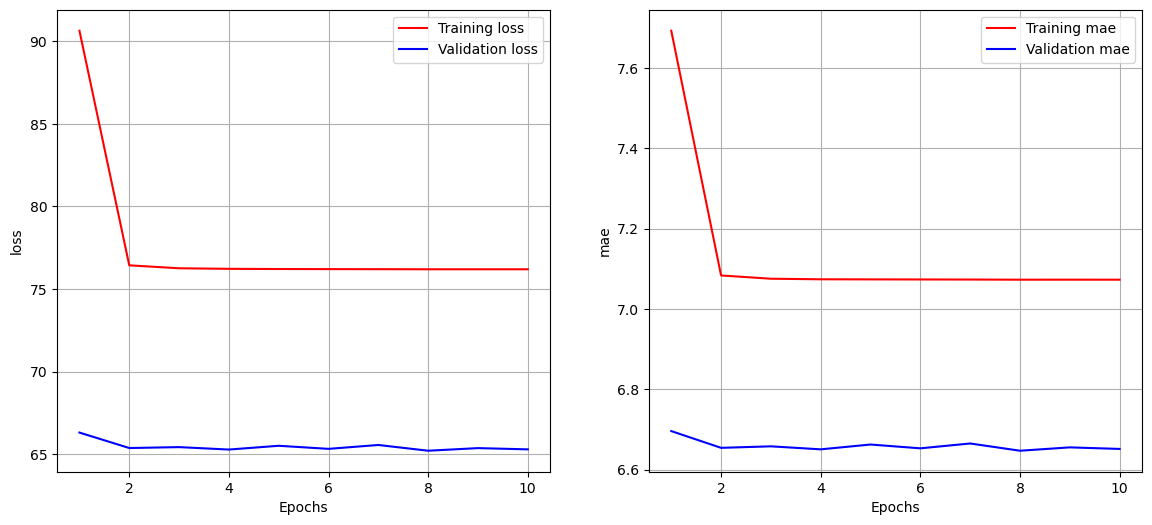

In [16]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'mae')

The training and validation losses are supposed to get to about the baseline.  But that is not happenning here.

### 10.2.4 Let's Try a 1D Convolutional Model

Since our input sequences feature daily cycles, perhaps a convolutional model
could work.  A temporal convnet could reuse the same representations across different days, much like a spatial
convnet can reuse the same representations across different locations in an image.

There are 1D and 3D convolution layers that work like the 2D layer, but on 1D and 3D tensors.

You could thus build 1D convnets, they are a great fit for any sequence data that follows the translation
invariance assumption (meaning that if you slide a window over the sequence, the content of the window should
follow the same properties independently of the location of the window.

The following model uses an initial window length of 24, so that we look at 24 hours of data at a time (one cycle).
As we downsample the sequences (via `MaxPooling1D` layers) we'll reduce the window size accordingly:

In [17]:
# define a model using 1D convolutions with a window of 24 initially, and max pooling layers
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [keras.callbacks.ModelCheckpoint("../models/jena_conv.keras",save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

In [18]:
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - loss: 30.6893 - mae: 4.2474 - val_loss: 19.3042 - val_mae: 3.4570
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - loss: 16.6030 - mae: 3.2316 - val_loss: 18.6454 - val_mae: 3.4465
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - loss: 14.7745 - mae: 3.0460 - val_loss: 16.0505 - val_mae: 3.1622
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - loss: 13.9139 - mae: 2.9531 - val_loss: 15.5926 - val_mae: 3.1108
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - loss: 13.2209 - mae: 2.8765 - val_loss: 17.1334 - val_mae: 3.2650
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - loss: 12.6844 - mae: 2.8190 - val_loss: 18.4754 - val_mae: 3.4028
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - loss: 12.2384 - mae: 2.7674 - val_loss: 15.0682 - val_mae: 3.0547
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - loss: 11.7769 - mae: 2.7175 - val_loss: 15.9274 - val_mae: 3.1432
Epoch 9/10
819/819 ━━━━━

In [19]:
model = keras.models.load_model("../models/jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 16.7855 - mae: 3.1962
Test MAE: 3.20


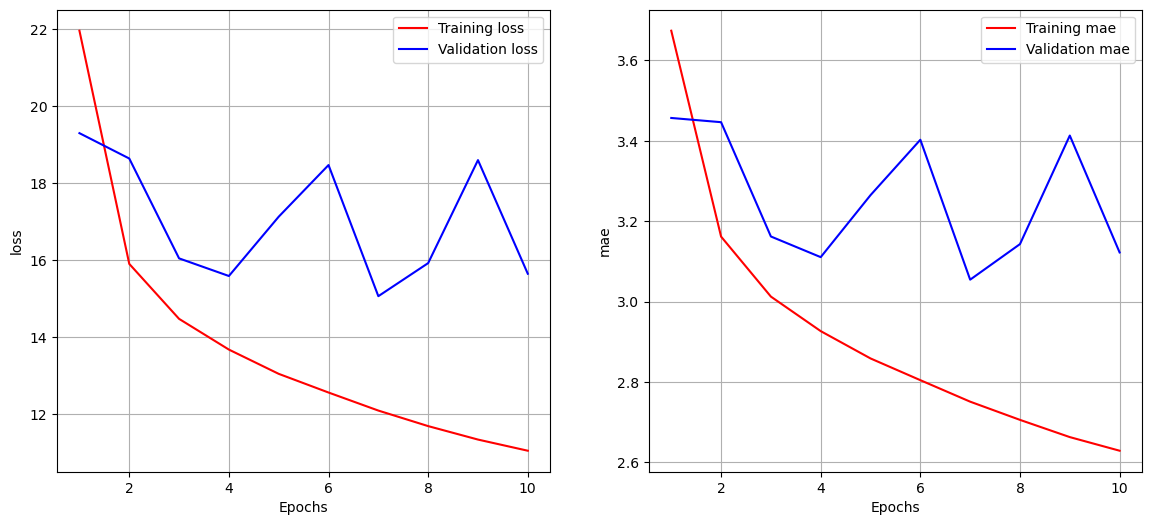

In [20]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'mae')

This model (is supposed to) perform even worse than the (correctly working) densely connected model.

Two things that may be wrong:

1. First, weather data doesn’t quite respect the translation invariance assumption.
   While the data does feature daily cycles, data from a morning follows different
   properties than data from an evening or from the middle of the night. Weather
   data is only translation-invariant for a very specific timescale.
2. Second, order in our data matters—a lot. The recent past is far more informative
   for predicting the next day’s temperature than data from five days ago. A
   1D convnet is not able to leverage this fact. In particular, our max pooling and
   global average pooling layers are largely destroying order information.

### 10.2.5 A First Recurrent Baseline

Neither the fully connected approach nor the 1D convolutional approach did well. 

The densely connected apprach first flattened the timeseries, which removed the notion
of time from the input data.

The convolutional approach treated every segment of the data in the same way, even applying pooling, which destroyed
order information.

Instead let's look at the data as what it is: a sequence where causality and order matter.

There's a family of neural network architectures designed specifically for use with time series: **recurrent neural networks**.

Let's start by using a Long Shor Term Memory (LSTM) layere, which as we will see in a bit, is a type of recurrent layer.

In [21]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [keras.callbacks.ModelCheckpoint("../models/jena_lstm.keras", save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

In [22]:
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - loss: 66.6386 - mae: 6.1898 - val_loss: 12.1577 - val_mae: 2.6687
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - loss: 11.9485 - mae: 2.6733 - val_loss: 9.4022 - val_mae: 2.3856
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - loss: 9.9499 - mae: 2.4546 - val_loss: 9.2823 - val_mae: 2.3649
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - loss: 9.2870 - mae: 2.3754 - val_loss: 9.1913 - val_mae: 2.3572
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - loss: 8.7616 - mae: 2.3164 - val_loss: 9.2578 - val_mae: 2.3632
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - loss: 8.4331 - mae: 2.2712 - val_loss: 9.3311 - val_mae: 2.3766
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - loss: 8.1890 - mae: 2.2370 - val_loss: 9.3107 - val_mae: 2.3738
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - loss: 8.0268 - mae: 2.2115 - val_loss: 9.1882 - val_mae: 2.3602
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━

In [23]:
model = keras.models.load_model("../models/jena_lstm.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 10.6674 - mae: 2.5623
Test MAE: 2.57


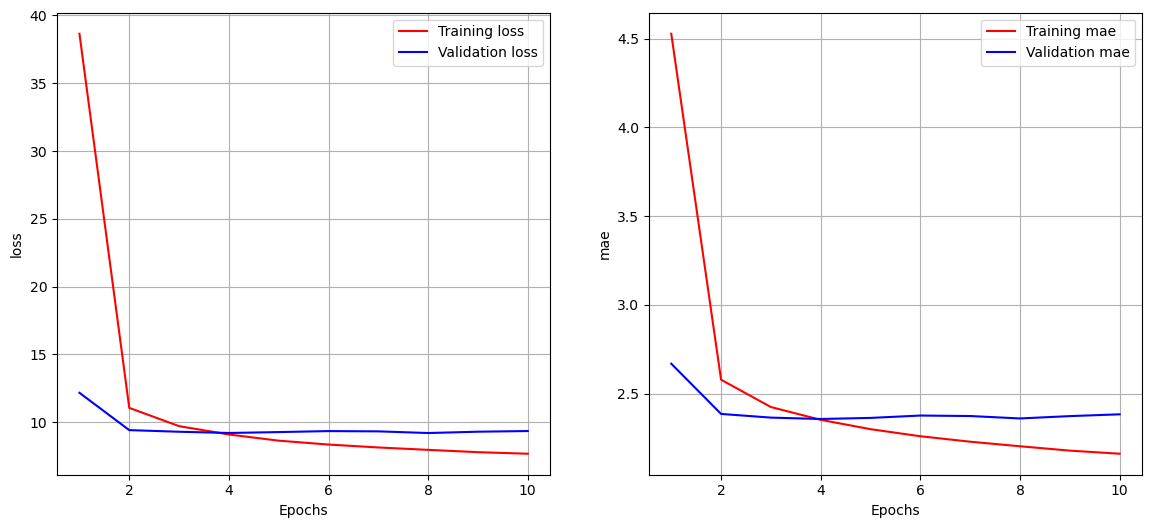

In [24]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'mae')

The model using a LSTM recurrent layer should usually get better results.  The validation MAE should
often achieve an MAE below 2.4.  Still not much better than the baseline, if even significant, but we can
improve on this.

By why does the LSTM model perform better than the densely connected one or the convnet?  And how can we refine and
improve its performance?

## Summary

<font color='blue'>
    
- A **timeseries** can be any data obtained via measurments at regular intervals.
- To work with timeseries effectively, you have to understand its **dynamics**: periodic cycles, trends over times
  and regular regime and sudden spikes.
- Most common timeseries task is **forecasting**.  But might also classify, detect events or detect anomalies in the timeseries.
- When working with timeseries, it is important to **always use validation and test data that is more recent than the training data**.
- Recurrent neural networks are specifically designed for data where causality and order matters in the inputs.